In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("healthcare_dataset.csv")

In [3]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


In [4]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                10000 non-null  object 
 1   Age                 10000 non-null  int64  
 2   Gender              10000 non-null  object 
 3   Blood Type          10000 non-null  object 
 4   Medical Condition   10000 non-null  object 
 5   Date of Admission   10000 non-null  object 
 6   Doctor              10000 non-null  object 
 7   Hospital            10000 non-null  object 
 8   Insurance Provider  10000 non-null  object 
 9   Billing Amount      10000 non-null  float64
 10  Room Number         10000 non-null  int64  
 11  Admission Type      10000 non-null  object 
 12  Discharge Date      10000 non-null  object 
 13  Medication          10000 non-null  object 
 14  Test Results        10000 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 1.1+

In [6]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [7]:
df.describe()

,Age,Billing Amount,Room Number
count,10000.000000,10000.000000,10000.000000
mean,51.452200,25516.806778,300.082000
std,19.588974,14067.292709,115.806027
min,18.000000,1000.180837,101.000000
25%,35.000000,13506.523967,199.000000
50%,52.000000,25258.112566,299.000000
75%,68.000000,37733.913727,400.000000
max,85.000000,49995.902283,500.000000


In [8]:
df.shape

(10000, 15)

In [9]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal


In [10]:
df["Medical Condition"].unique()

array(['Diabetes', 'Asthma', 'Obesity', 'Arthritis', 'Hypertension',
       'Cancer'], dtype=object)

In [15]:
df[["Medical Condition","Admission Type"]].count()

Medical Condition    10000
Admission Type       10000
dtype: int64

In [16]:
condition_admission_counts = df.groupby(['Medical Condition', 'Admission Type']).size().unstack(fill_value=0)

In [17]:
condition_admission_counts

Admission Type,Elective,Emergency,Urgent
Medical Condition,,,
Arthritis,569,529,552
Asthma,570,556,582
Cancer,555,578,570
Diabetes,528,557,538
Hypertension,515,578,595
Obesity,505,569,554


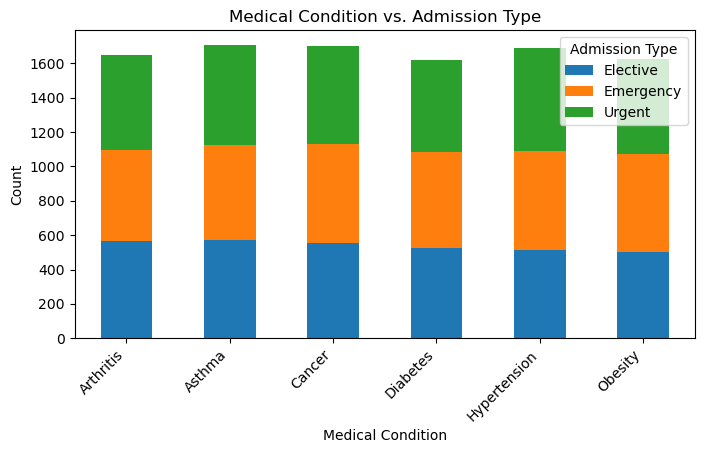

In [19]:
condition_admission_counts.plot(kind='bar', stacked=True, figsize=(8, 4))

plt.xlabel('Medical Condition')
plt.ylabel('Count')
plt.title('Medical Condition vs. Admission Type')

plt.xticks(rotation=45, ha='right')
plt.legend(title='Admission Type')

plt.show()

In [23]:
Mean_billing_amount = df[["Medical Condition", "Billing Amount"]].groupby("Medical Condition").mean()

In [24]:
Mean_billing_amount

,Billing Amount
Medical Condition,
Arthritis,25187.631255
Asthma,25416.869895
Cancer,25539.096133
Diabetes,26060.116129
Hypertension,25198.033973
Obesity,25720.842683


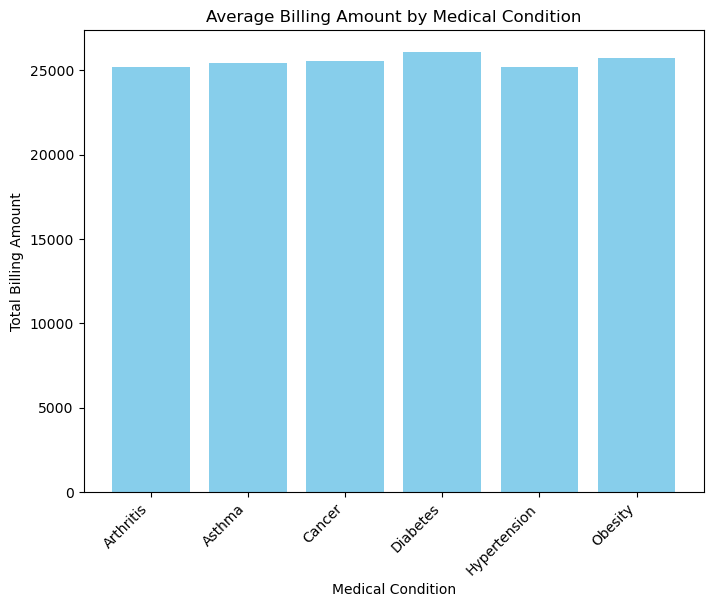

In [25]:
total_billing_by_condition = df.groupby('Medical Condition')['Billing Amount'].mean().reset_index()

plt.figure(figsize=(8, 6))
plt.bar(total_billing_by_condition['Medical Condition'], total_billing_by_condition['Billing Amount'], color='skyblue')

plt.xlabel('Medical Condition')
plt.ylabel('Total Billing Amount')
plt.title('Average Billing Amount by Medical Condition')

plt.xticks(rotation=45, ha='right')  

plt.show()

In [27]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                10000 non-null  object        
 1   Age                 10000 non-null  int64         
 2   Gender              10000 non-null  object        
 3   Blood Type          10000 non-null  object        
 4   Medical Condition   10000 non-null  object        
 5   Date of Admission   10000 non-null  datetime64[ns]
 6   Doctor              10000 non-null  object        
 7   Hospital            10000 non-null  object        
 8   Insurance Provider  10000 non-null  object        
 9   Billing Amount      10000 non-null  float64       
 10  Room Number         10000 non-null  int64         
 11  Admission Type      10000 non-null  object        
 12  Discharge Date      10000 non-null  datetime64[ns]
 13  Medication          10000 non-null  object     

In [30]:
df['Recovery_Days'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

In [31]:
df['Recovery_Days']

0       14
1       14
2       30
3        1
4       24
        ..
9995     4
9996    23
9997    14
9998    20
9999    24
Name: Recovery_Days, Length: 10000, dtype: int64

In [32]:
mean_recovery = df.groupby('Medical Condition')['Recovery_Days'].mean()
mean_recovery

Medical Condition
Arthritis       15.990303
Asthma          15.481265
Cancer          15.479742
Diabetes        15.574245
Hypertension    15.430095
Obesity         15.421990
Name: Recovery_Days, dtype: float64

In [33]:
diabetes_data = df[df['Medical Condition'] == 'Diabetes']

In [34]:
diabetes_data

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Recovery_Days
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive,14
8,Ryan Hayes,33,Male,A+,Diabetes,2020-12-17,Kristin Dunn,"Smith, Edwards and Obrien",Aetna,24903.037270,215,Elective,2020-12-22,Aspirin,Abnormal,5
12,Christina Williams,85,Female,A+,Diabetes,2021-11-29,Laura Roberts,"Malone, Thompson and Mejia",Aetna,4835.945650,444,Elective,2021-12-14,Aspirin,Inconclusive,15
13,William Page,72,Female,A+,Diabetes,2021-07-29,James Carney,Richardson-Powell,Cigna,13669.377744,492,Elective,2021-08-14,Aspirin,Normal,16
16,Olivia Gonzalez,64,Male,AB-,Diabetes,2019-11-15,Clayton Mcknight,Cunningham and Sons,Aetna,17394.994264,315,Elective,2019-12-04,Aspirin,Inconclusive,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9961,Joseph Wilson,78,Female,A+,Diabetes,2021-11-05,Sarah Novak,Wilson-Davis,Cigna,21106.014702,340,Elective,2021-11-22,Penicillin,Inconclusive,17
9962,Jenny Ho,48,Male,AB-,Diabetes,2022-09-13,Julie Harrison,Knight-Marshall,UnitedHealthcare,23271.652611,120,Elective,2022-09-27,Ibuprofen,Inconclusive,14
9971,Gregory Torres,56,Female,A+,Diabetes,2021-07-25,Robert Wilson,Mcpherson Group,Blue Cross,38831.707893,151,Emergency,2021-08-11,Penicillin,Abnormal,17
9984,Erica Crawford,72,Male,AB+,Diabetes,2021-09-17,Katie Huber,Ramirez PLC,Medicare,37181.841257,151,Emergency,2021-10-02,Lipitor,Normal,15


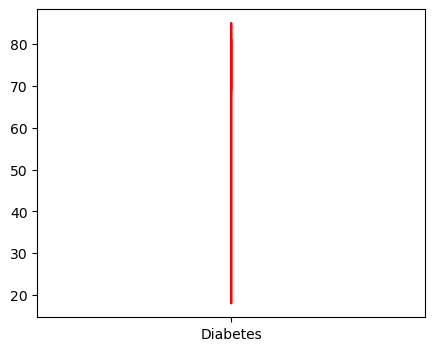

In [35]:
diabetes_data = df[df['Medical Condition'] == 'Diabetes']
plt.figure(figsize=(5,4))
plt.plot(diabetes_data['Medical Condition'], diabetes_data['Age'], color = 'red') 
plt.show()

In [45]:
medication = df.groupby(["Medical Condition","Medication"]).size().unstack()

In [46]:
medication

Medication,Aspirin,Ibuprofen,Lipitor,Paracetamol,Penicillin
Medical Condition,,,,,
Arthritis,322,320,318,324,366
Asthma,370,340,346,310,342
Cancer,291,352,350,346,364
Diabetes,335,301,326,327,334
Hypertension,328,335,356,323,346
Obesity,322,328,319,332,327


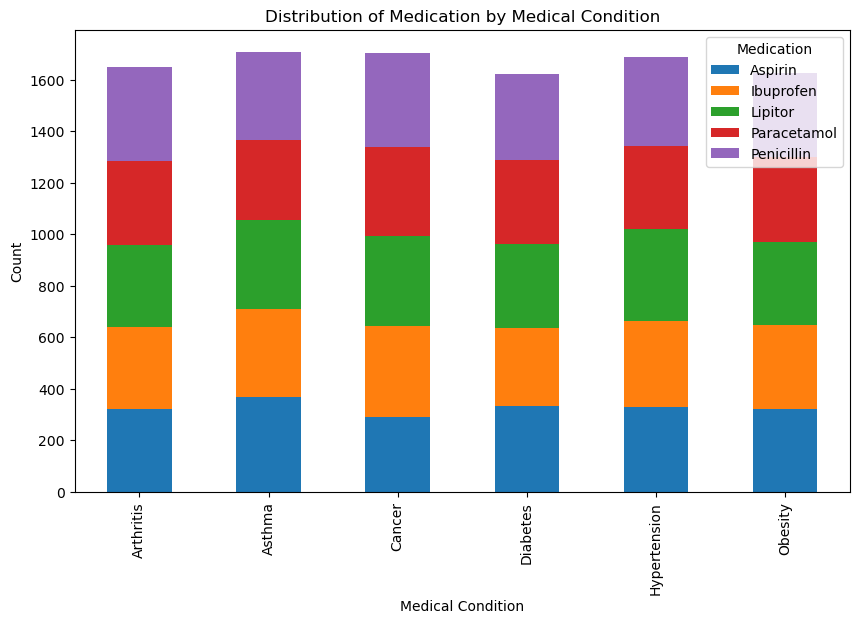

In [47]:
medication.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.xlabel('Medical Condition')
plt.ylabel('Count')
plt.title('Distribution of Medication by Medical Condition')

plt.show()

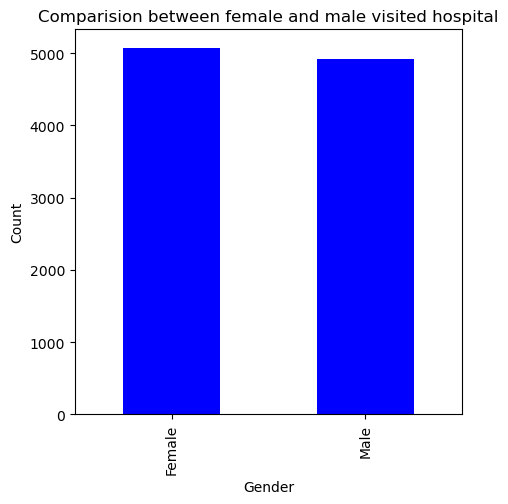

In [50]:
Gender=df['Gender'].value_counts()
Gender.plot(kind='bar',color='blue', figsize=(5,5))
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Comparision between female and male visited hospital')
plt.show()